In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
def get_data_loaders(batch_size=64):
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
    data = pd.read_csv(url, sep='\t', header=None)
    
    # Chuẩn hóa (Z-score)
    data = (data - data.mean()) / data.std()
    
    features = torch.tensor(data.iloc[:, :-1].values, dtype=torch.float32)
    labels = torch.tensor(data.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
    
    dataset = TensorDataset(features, labels)
    return DataLoader(dataset, batch_size, shuffle=True), features.shape[1]

def train_model(config):
    # Lấy dữ liệu
    train_iter, input_dim = get_data_loaders(config['batch_size'])
    
    # Model & Loss
    model = nn.Linear(input_dim, 1)
    loss_fn = nn.MSELoss()
    
    # Optimizer (Nơi tinh chỉnh lr và momentum)
    optimizer = torch.optim.SGD(
        model.parameters(), 
        lr=config['lr'], 
        momentum=config['momentum']
    )
    
    loss_history = []
    
    print(f"Bắt đầu huấn luyện: lr={config['lr']}, momentum={config['momentum']}")
    
    for epoch in range(config['epochs']):
        epoch_loss = 0
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss_fn(model(X), y)
            l.backward()
            optimizer.step()
            epoch_loss += l.item()
        
        avg_loss = epoch_loss / len(train_iter)
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config['epochs']} | Loss: {avg_loss:.4f}")
            
    return loss_history

def plot_loss(loss_history, config):
    plt.figure(figsize=(4, 3))
    plt.plot(loss_history, label=f"lr={config['lr']}, mom={config['momentum']}")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.grid(True)
    plt.show()

Bắt đầu huấn luyện: lr=0.02, momentum=0.5
Epoch 10/20 | Loss: 0.4920
Epoch 20/20 | Loss: 0.4895


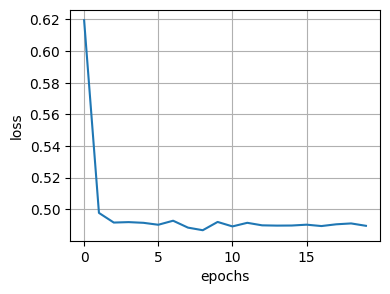

In [19]:
config = {
    'lr': 0.02,        # Tốc độ học
    'momentum': 0.5,     # Hệ số động lượng (thử 0.0, 0.5, 0.9, 0.99)
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.02, momentum=0.9
Epoch 10/20 | Loss: 0.5099
Epoch 20/20 | Loss: 0.5091


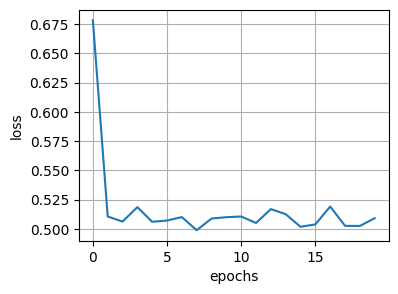

In [ ]:
# momentum lớn -> quán tính mạnh -> khó dừng khi gặp global minima

config = {
    'lr': 0.02,        # Tốc độ học
    'momentum': 0.9,     # Hệ số động lượng (thử 0.0, 0.5, 0.9, 0.99)
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.005, momentum=0.9
Epoch 10/20 | Loss: 0.4959
Epoch 20/20 | Loss: 0.4891


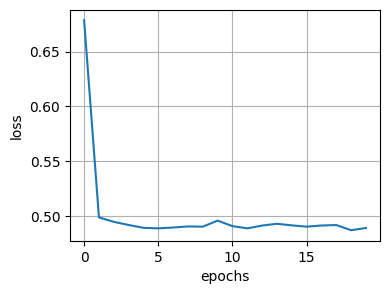

In [ ]:
# giảm lr để cập nhật chậm sẽ giải quyết vấn đề 

config = {
    'lr': 0.005,        # Tốc độ học
    'momentum': 0.9,     # Hệ số động lượng (thử 0.0, 0.5, 0.9, 0.99)
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.01, momentum=0.5
Epoch 10/20 | Loss: 0.4876
Epoch 20/20 | Loss: 0.4875


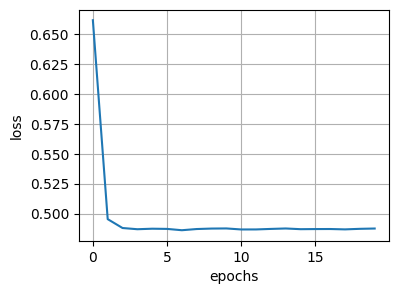

In [ ]:
# cân bằng lr và momentum sẽ được kết quả mượt mà hơn

config = {
    'lr': 0.01,        # Tốc độ học
    'momentum': 0.5,     # Hệ số động lượng
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)